# Causal Machine Learning — Entrega Intermediária
## Prevenção de Churn em Telecomunicações via Inferência Causal

**Grupo:** Eduardo Assis Tomich · Lucas Augusto da Silva Gonçalves · Lucas Vitor da Silva Ramos · Rafael Vinícius dos Santos

**Disciplina:** Causal Machine Learning — UFMG 2026/1

---

### Contexto do Problema

No setor de telecomunicações, o custo de aquisição de clientes (CAC) supera significativamente o de retenção, tornando o *churn* um desafio crítico. Modelos preditivos tradicionais identificam clientes com alto risco de cancelamento, mas **não prescrevem a ação ideal**.

O projeto completo formula a prevenção de churn como um problema de **Unit Selection** (Pearl, Nível 3), onde o objetivo é identificar *Compliers* — clientes que só permanecerão se receberem um tratamento específico.

### Formulação das Variáveis

| Símbolo | Descrição | Variáveis no Dataset |
|---------|-----------|---------------------|
| **C** (Covariáveis) | Atributos observáveis do cliente | `tenure`, `Contract`, `MonthlyCharges`, `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `InternetService`, etc. |
| **X** (Tratamentos) | Intervenções de retenção | `TechSupport`, `StreamingTV`, `StreamingMovies` |
| **Y** (Desfecho) | Retenção do cliente | `Churn` invertido: **Y=1 → Ficou**, **Y=0 → Cancelou** |

### Escopo desta Entrega

1. Limpeza e preparação dos dados
2. Análise Exploratória de Dados (EDA)
3. Modelos preditivos baseline (Regressão Logística + Random Forest)
4. DAG Causal do problema

---
## 1. Setup e Carregamento dos Dados

In [94]:
%pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn networkx

Note: you may need to restart the kernel to use updated packages.


In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
    PrecisionRecallDisplay,
    brier_score_loss,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

In [96]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print(f"Dataset baixado em: {path}")

Dataset baixado em: /Users/rafael/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [97]:
import os

csv_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw = pd.read_csv(csv_file)

print(f"Shape: {df_raw.shape}")
print(f"Colunas: {list(df_raw.columns)}")
df_raw.head()

Shape: (7043, 21)
Colunas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [98]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

---
## 2. Limpeza de Dados

Problemas conhecidos do dataset:
- `TotalCharges` está como `object` (strings vazias em clientes com `tenure=0`)
- `customerID` não é feature útil
- `Churn` precisa ser convertido para numérico com Y=1 representando **retenção**

In [99]:
df = df_raw.copy()

# Remover customerID
df = df.drop(columns=["customerID"])

# Converter TotalCharges para numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Verificar nulos gerados pela conversão
nulos_tc = df["TotalCharges"].isna().sum()
print(f"Valores nulos em TotalCharges após conversão: {nulos_tc}")
print(f"Esses clientes têm tenure = 0:")
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Valores nulos em TotalCharges após conversão: 11
Esses clientes têm tenure = 0:


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [100]:
# Clientes com tenure=0 e TotalCharges nulo: preencher com 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Criar variável target Y: 1 = Retenção (No Churn), 0 = Cancelou (Churn)
df["Y"] = (df["Churn"] == "No").astype(int)
df = df.drop(columns=["Churn"])

print(f"Distribuição de Y (1=Ficou, 0=Cancelou):")
print(df["Y"].value_counts())
print(f"\nNulos restantes por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("Nenhum valor nulo restante.")

Distribuição de Y (1=Ficou, 0=Cancelou):
Y
1    5174
0    1869
Name: count, dtype: int64

Nulos restantes por coluna:
Series([], dtype: int64)
Nenhum valor nulo restante.


In [101]:
# Definir grupos de variáveis conforme a formulação do projeto
TREATMENTS = ["TechSupport", "StreamingTV", "StreamingMovies"]
TARGET = "Y"

COVARIATES = [
    col for col in df.columns if col not in TREATMENTS + [TARGET]
]

print(f"Covariáveis (C): {COVARIATES}")
print(f"Tratamentos (X): {TREATMENTS}")
print(f"Desfecho (Y): {TARGET}")

Covariáveis (C): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Tratamentos (X): ['TechSupport', 'StreamingTV', 'StreamingMovies']
Desfecho (Y): Y


In [102]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Y
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.734630
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,1.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [103]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Y                     int64
dtype: object

---
## 3. Análise Exploratória de Dados (EDA)

### 3.1 Distribuição do Target (Retenção vs. Churn)

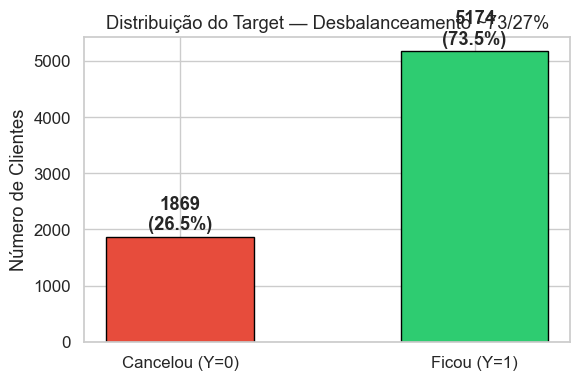

In [104]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["Y"].value_counts()
labels = ["Cancelou (Y=0)", "Ficou (Y=1)"]
colors = ["#e74c3c", "#2ecc71"]
bars = ax.bar(labels, [counts[0], counts[1]], color=colors, edgecolor="black", width=0.5)

for bar, count in zip(bars, [counts[0], counts[1]]):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{count}\n({pct:.1f}%)", ha="center", va="bottom", fontweight="bold")

ax.set_ylabel("Número de Clientes")
ax.set_title("Distribuição do Target — Desbalanceamento ~73/27%")
plt.tight_layout()
plt.show()

### 3.2 Features Demográficas vs. Retenção

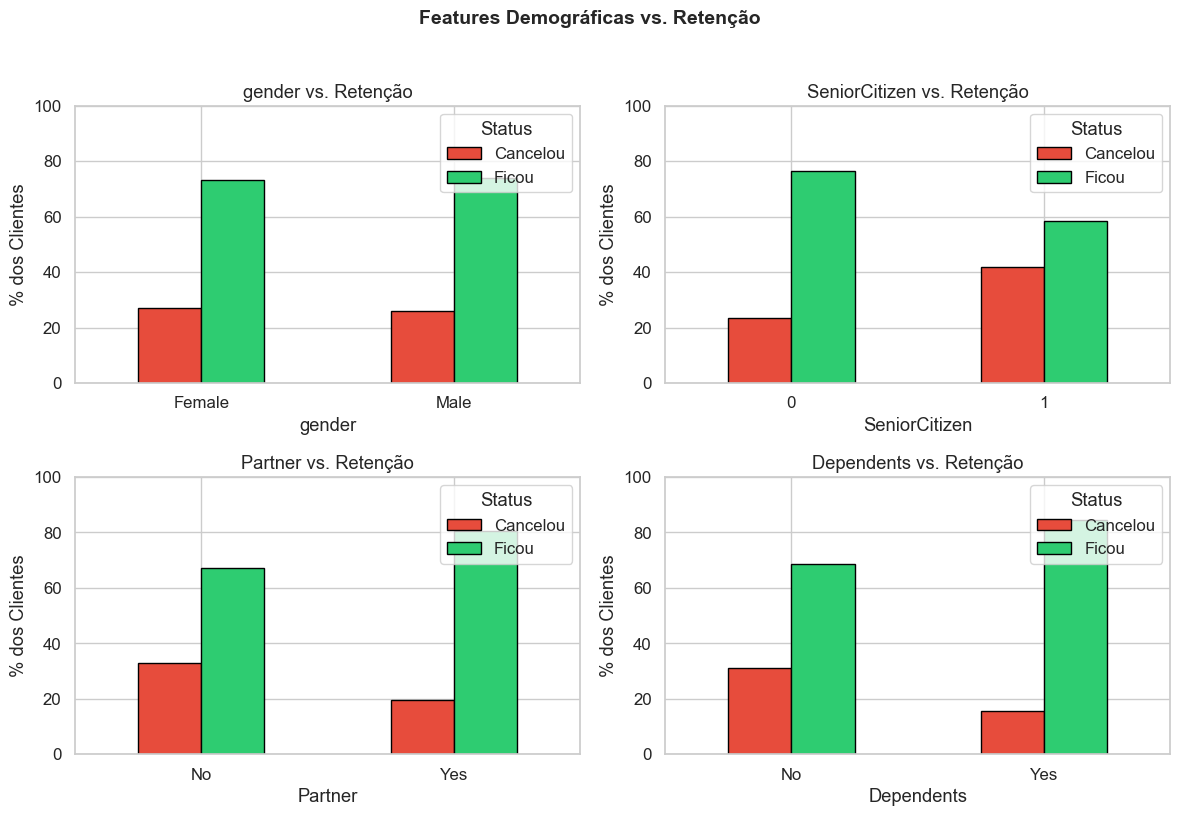

In [105]:
demo_features = ["gender", "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(demo_features):
    ax = axes[i]
    ct = pd.crosstab(df[feat], df["Y"], normalize="index") * 100
    ct.columns = ["Cancelou", "Ficou"]
    ct.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"], edgecolor="black", rot=0)
    ax.set_title(f"{feat} vs. Retenção")
    ax.set_ylabel("% dos Clientes")
    ax.set_xlabel(feat)
    ax.legend(title="Status", loc="upper right")
    ax.set_ylim(0, 100)

plt.suptitle("Features Demográficas vs. Retenção", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Features de Conta vs. Retenção

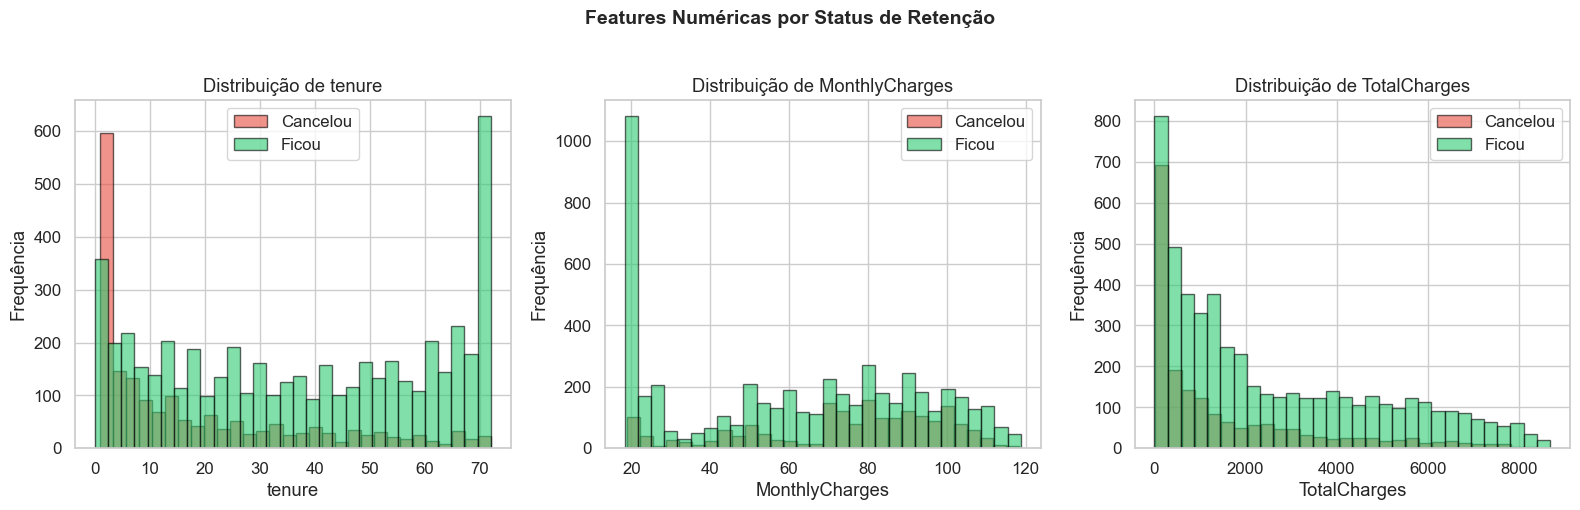

In [106]:
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feat in enumerate(num_features):
    ax = axes[i]
    for y_val, label, color in [(0, "Cancelou", "#e74c3c"), (1, "Ficou", "#2ecc71")]:
        subset = df[df["Y"] == y_val][feat]
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor="black")
    ax.set_title(f"Distribuição de {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Frequência")
    ax.legend()

plt.suptitle("Features Numéricas por Status de Retenção", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

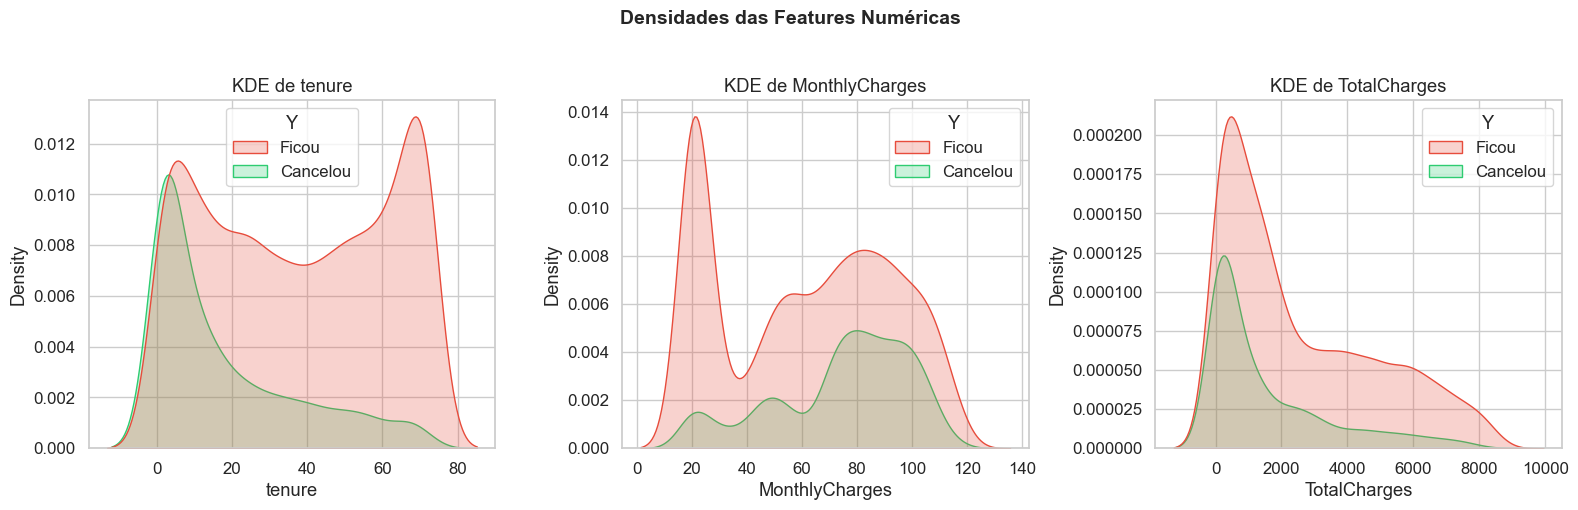

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feat in enumerate(num_features):
    ax = axes[i]
    sns.kdeplot(data=df, x=feat, hue=df["Y"].map({0: "Cancelou", 1: "Ficou"}),
                fill=True, ax=ax, palette=["#e74c3c", "#2ecc71"])
    ax.set_title(f"KDE de {feat}")

plt.suptitle("Densidades das Features Numéricas", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Features de Serviço vs. Retenção

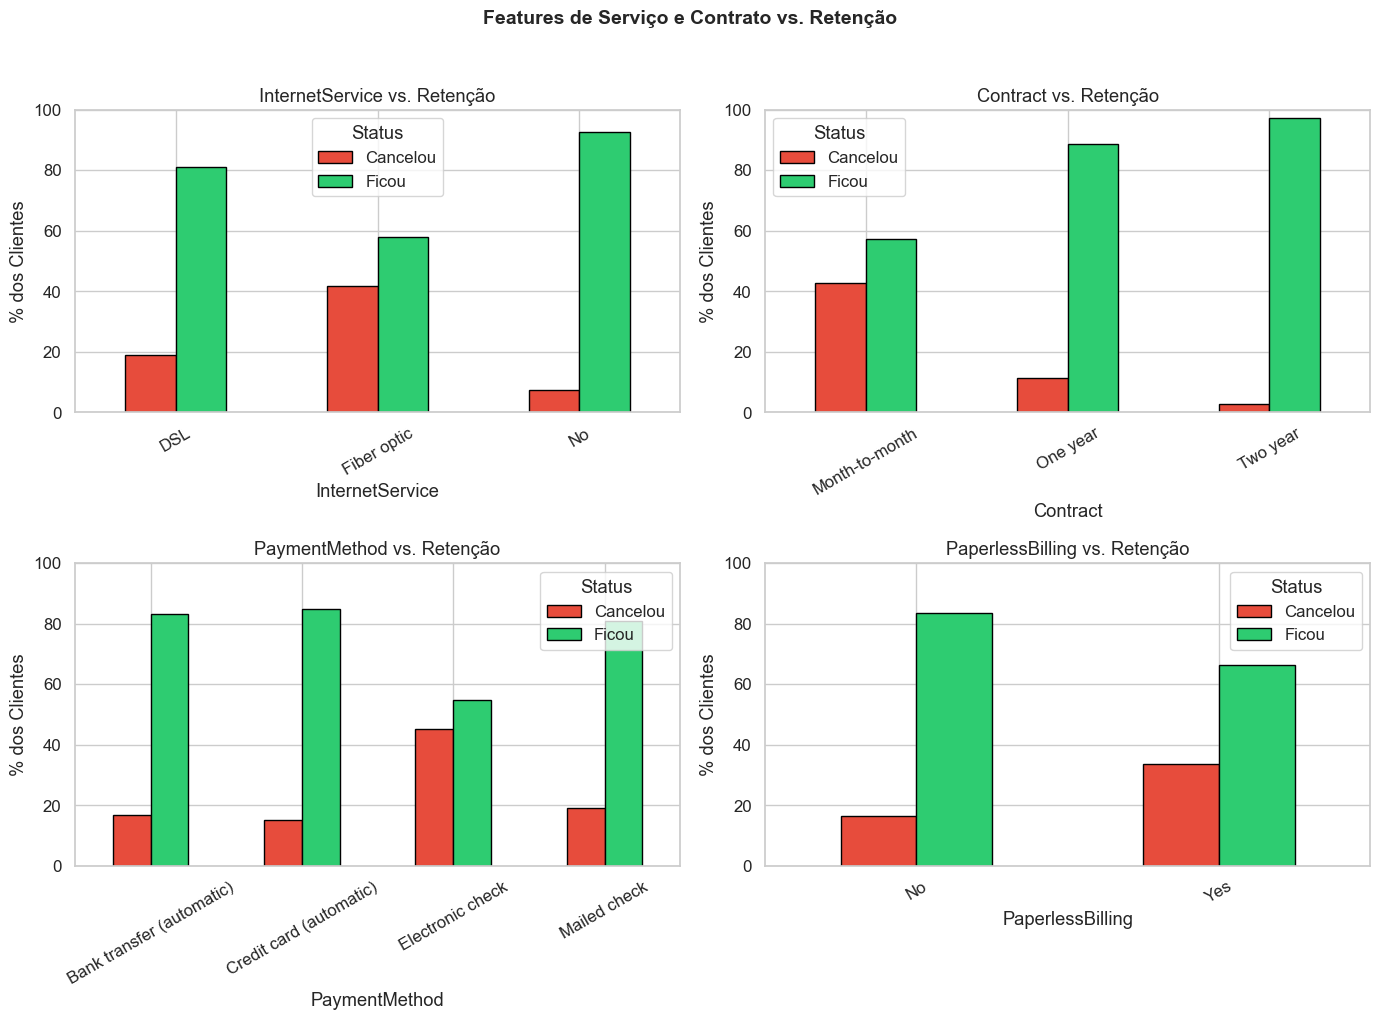

In [108]:
service_features = ["InternetService", "Contract", "PaymentMethod", "PaperlessBilling"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(service_features):
    ax = axes[i]
    ct = pd.crosstab(df[feat], df["Y"], normalize="index") * 100
    ct.columns = ["Cancelou", "Ficou"]
    ct.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"], edgecolor="black", rot=30)
    ax.set_title(f"{feat} vs. Retenção")
    ax.set_ylabel("% dos Clientes")
    ax.set_xlabel(feat)
    ax.legend(title="Status")
    ax.set_ylim(0, 100)

plt.suptitle("Features de Serviço e Contrato vs. Retenção", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Variáveis de Tratamento (X) vs. Retenção

Estas são as variáveis de tratamento do projeto: `TechSupport`, `StreamingTV`, `StreamingMovies`. Na entrega final, estimaremos o efeito causal (CATE) de cada uma sobre a retenção. Aqui analisamos a **associação observacional** — que inclui confundimento e não deve ser interpretada como efeito causal.

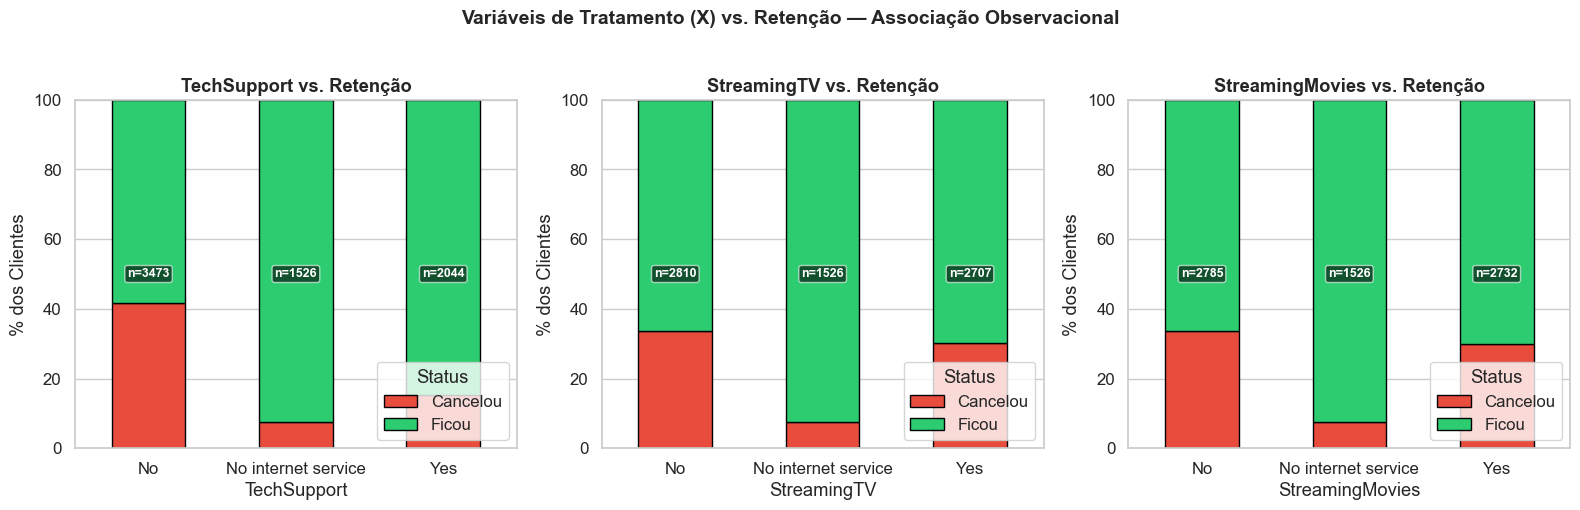

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, treat in enumerate(TREATMENTS):
    ax = axes[i]
    ct = pd.crosstab(df[treat], df["Y"])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.columns = ["Cancelou", "Ficou"]

    ct_pct.plot(kind="bar", stacked=True, ax=ax,
                color=["#e74c3c", "#2ecc71"], edgecolor="black", rot=0)
    ax.set_title(f"{treat} vs. Retenção", fontweight="bold")
    ax.set_ylabel("% dos Clientes")
    ax.set_xlabel(treat)
    ax.legend(title="Status", loc="lower right")
    ax.set_ylim(0, 100)

    # Anotar contagens
    for j, (idx, row) in enumerate(ct_pct.iterrows()):
        total = ct.loc[idx].sum()
        ax.text(j, 50, f"n={total}", ha="center", va="center",
                fontsize=9, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6))

plt.suptitle("Variáveis de Tratamento (X) vs. Retenção — Associação Observacional",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [110]:
# Taxa de retenção bruta por tratamento (associação, não causal)
print("Taxa de retenção (Y=1) por valor de cada tratamento:\n")
for treat in TREATMENTS:
    rates = df.groupby(treat)["Y"].mean().round(3)
    print(f"--- {treat} ---")
    for val, rate in rates.items():
        print(f"  {val}: {rate:.1%} de retenção")
    print()

Taxa de retenção (Y=1) por valor de cada tratamento:

--- TechSupport ---
  No: 58.4% de retenção
  No internet service: 92.6% de retenção
  Yes: 84.8% de retenção

--- StreamingTV ---
  No: 66.5% de retenção
  No internet service: 92.6% de retenção
  Yes: 69.9% de retenção

--- StreamingMovies ---
  No: 66.3% de retenção
  No internet service: 92.6% de retenção
  Yes: 70.1% de retenção



### 3.5.1 Prova Empírica do Viés de Seleção

/var/folders/b3/ph13z24n3zd57h9169_8_2hh0000gn/T/ipykernel_1864/317552303.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="TechSupport", y="tenure",


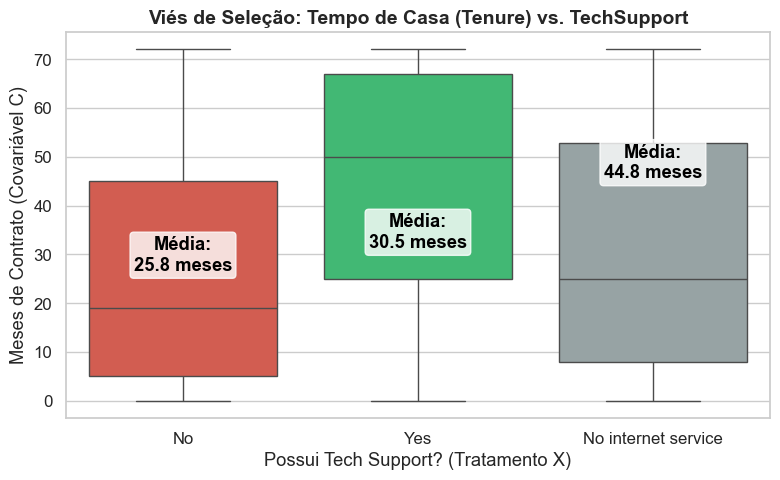

In [ ]:
# Clientes com Suporte Técnico tendem a ter contratos muito mais antigos.

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="TechSupport", y="tenure", 
            palette={"No": "#e74c3c", "Yes": "#2ecc71", "No internet service": "#95a5a6"}, ax=ax)

ax.set_title("Viés de Seleção: Tempo de Casa (Tenure) vs. TechSupport", fontsize=14, fontweight="bold")
ax.set_xlabel("Possui Tech Support? (Tratamento X)")
ax.set_ylabel("Meses de Contrato (Covariável C)")

# Anotação das médias
medias = df.groupby("TechSupport")["tenure"].mean()
for i, key in enumerate(["No", "No internet service", "Yes"]):
    ax.text(i, medias[key], f"Média:\n{medias[key]:.1f} meses", 
            ha="center", va="bottom", fontweight="bold", color="black", 
            bbox=dict(facecolor="white", alpha=0.8, boxstyle="round,pad=0.2"))

plt.tight_layout()
plt.show()

### 3.6 Matriz de Correlação

/var/folders/b3/ph13z24n3zd57h9169_8_2hh0000gn/T/ipykernel_1864/2640657918.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include="object").columns:


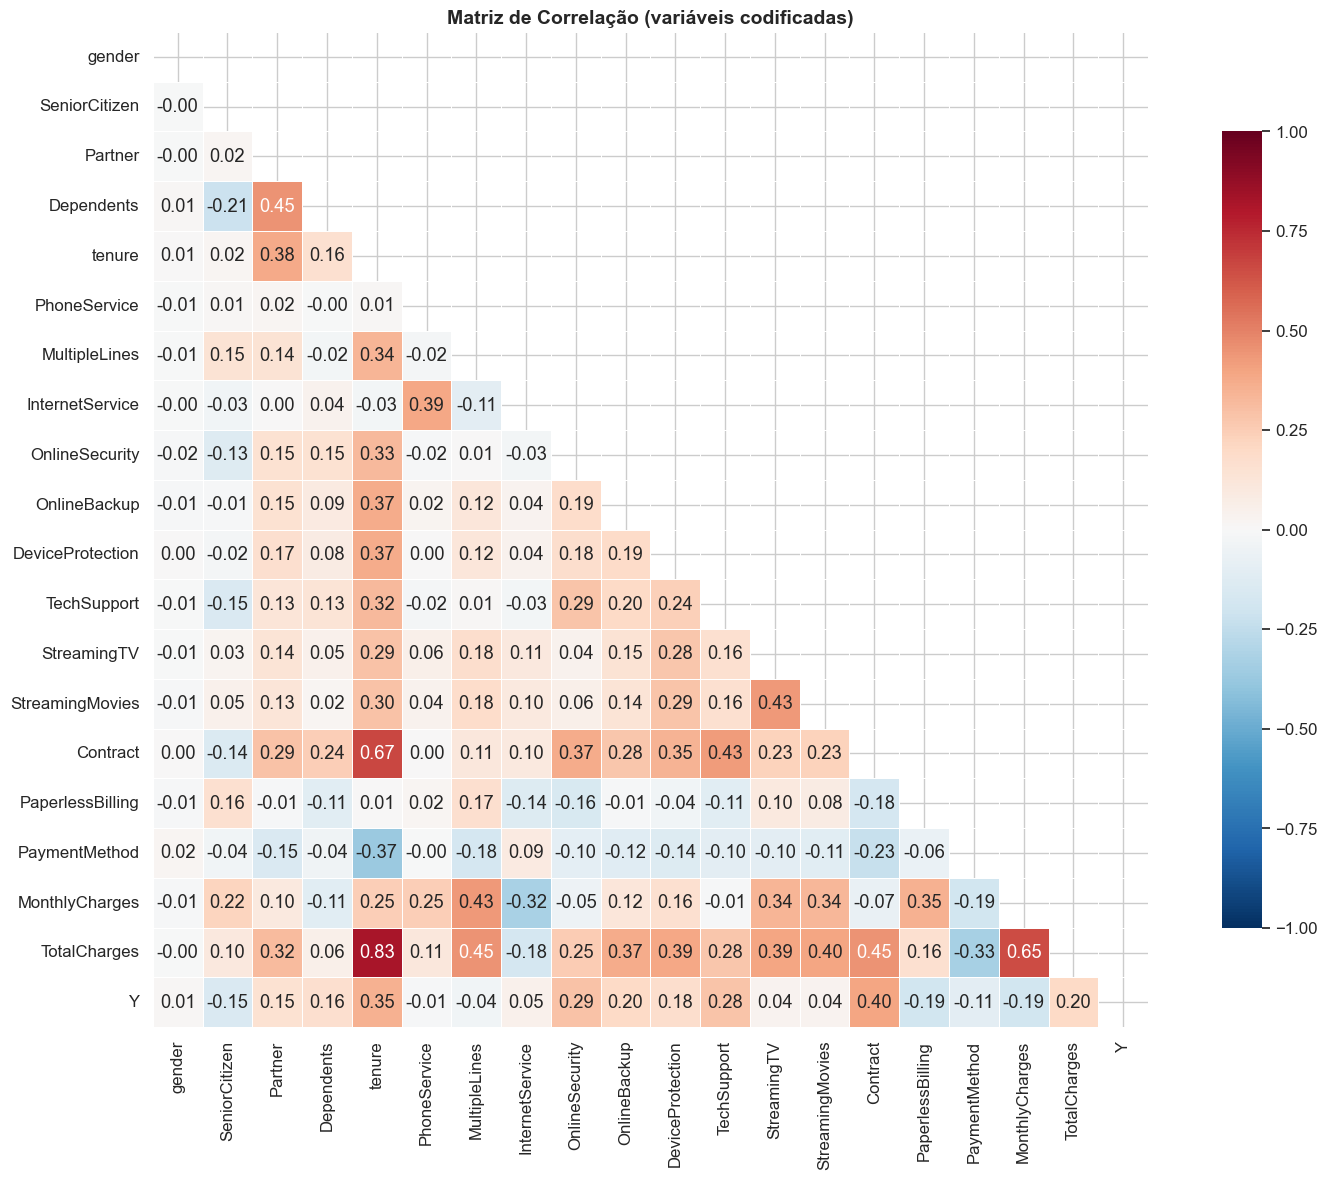

In [112]:
# Codificar variáveis categóricas para a correlação
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = df_encoded[col].astype("category").cat.codes

fig, ax = plt.subplots(figsize=(16, 12))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de Correlação (variáveis codificadas)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [113]:
# Correlações mais fortes com Y
corr_with_y = corr["Y"].drop("Y").sort_values(key=abs, ascending=False)
print("Top correlações com Y (Retenção):\n")
print(corr_with_y.head(10).to_string())

Top correlações com Y (Retenção):

Contract            0.396713
tenure              0.352229
OnlineSecurity      0.289309
TechSupport         0.282492
TotalCharges        0.198324
OnlineBackup        0.195525
MonthlyCharges     -0.193356
PaperlessBilling   -0.191825
DeviceProtection    0.178134
Dependents          0.164221


---
## 4. Pré-processamento para Modelos de ML

Para os modelos preditivos baseline, usamos **todas as features** (C + X) para prever Y. O objetivo aqui é avaliar a capacidade preditiva, não o efeito causal — essa distinção será central na entrega final.

In [114]:
# Separar features e target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# One-hot encoding das categóricas
X = pd.get_dummies(X, drop_first=True)

print(f"Features após encoding: {X.shape[1]} colunas")
print(f"Exemplos: {list(X.columns[:10])} ...")

Features após encoding: 30 colunas
Exemplos: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes'] ...


In [115]:
# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras (Y=1: {y_train.mean():.1%})")
print(f"Teste:  {X_test.shape[0]} amostras (Y=1: {y_test.mean():.1%})")

Treino: 5634 amostras (Y=1: 73.5%)
Teste:  1409 amostras (Y=1: 73.5%)


In [116]:
# Padronizar features numéricas
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Features numéricas padronizadas.")
X_train[num_cols].describe().round(2)

Features numéricas padronizadas.


,tenure,MonthlyCharges,TotalCharges
count,5634.00,5634.00,5634.00
mean,0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-1.31,-1.56,-1.00
25%,-0.99,-0.95,-0.83
50%,-0.13,0.18,-0.39
75%,0.96,0.83,0.67
max,1.61,1.80,2.82


---
## 5. Modelos Preditivos Baseline

Treinamos dois modelos simples para estabelecer um baseline preditivo. As métricas escolhidas seguem a seção 9 do projeto:

- **PR-AUC** (Precision-Recall AUC): preferível ao ROC-AUC devido ao desbalanceamento. Calculado em relação à classe minoritária (Cancelou, Y=0).
- **Brier Score**: avalia a calibração das probabilidades — fundamental para a estimação de CATE na entrega final.

### 5.1 Regressão Logística

In [117]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# PR-AUC calculado para a classe minoritária (Y=0 = Cancelou)
# average_precision_score por padrão calcula para pos_label=1,
# então invertemos para focar na classe minoritária
pr_auc_lr = average_precision_score(y_test, 1 - y_prob_lr, pos_label=0)
brier_lr = brier_score_loss(y_test, y_prob_lr)

print("=" * 50)
print("REGRESSÃO LOGÍSTICA")
print("=" * 50)
print(f"PR-AUC (classe minoritária): {pr_auc_lr:.4f}")
print(f"Brier Score:                 {brier_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["Cancelou (0)", "Ficou (1)"]))

REGRESSÃO LOGÍSTICA
PR-AUC (classe minoritária): 0.6096
Brier Score:                 0.1415

              precision    recall  f1-score   support

Cancelou (0)       0.64      0.52      0.57       374
   Ficou (1)       0.84      0.89      0.86      1035

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



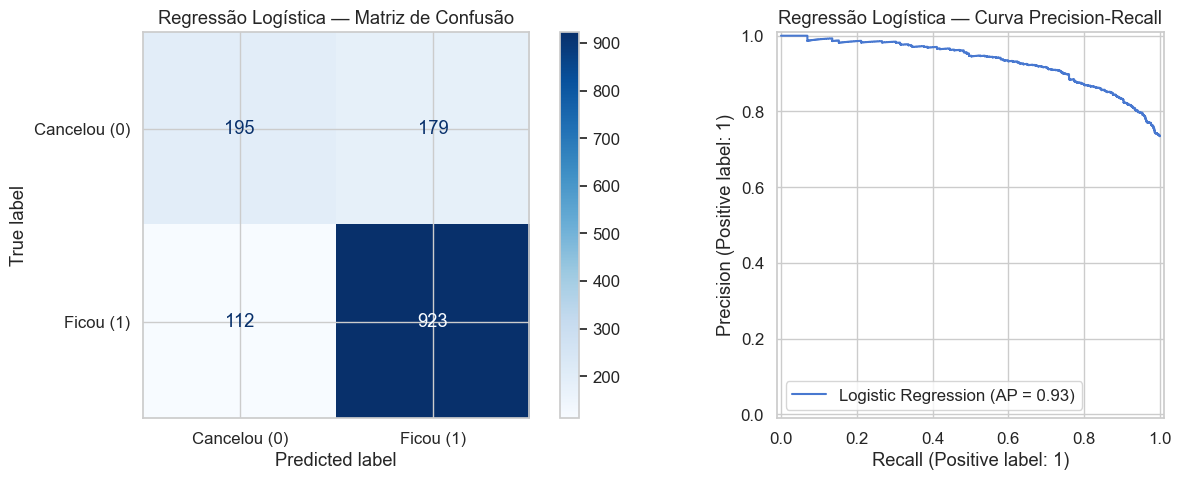

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=["Cancelou (0)", "Ficou (1)"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Regressão Logística — Matriz de Confusão")

# Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_lr, pos_label=1,
    name="Logistic Regression", ax=axes[1]
)
axes[1].set_title("Regressão Logística — Curva Precision-Recall")

plt.tight_layout()
plt.show()

### 5.2 Random Forest

In [119]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

pr_auc_rf = average_precision_score(y_test, 1 - y_prob_rf, pos_label=0)
brier_rf = brier_score_loss(y_test, y_prob_rf)

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(f"PR-AUC (classe minoritária): {pr_auc_rf:.4f}")
print(f"Brier Score:                 {brier_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["Cancelou (0)", "Ficou (1)"]))

RANDOM FOREST
PR-AUC (classe minoritária): 0.6423
Brier Score:                 0.1388

              precision    recall  f1-score   support

Cancelou (0)       0.68      0.48      0.56       374
   Ficou (1)       0.83      0.92      0.87      1035

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



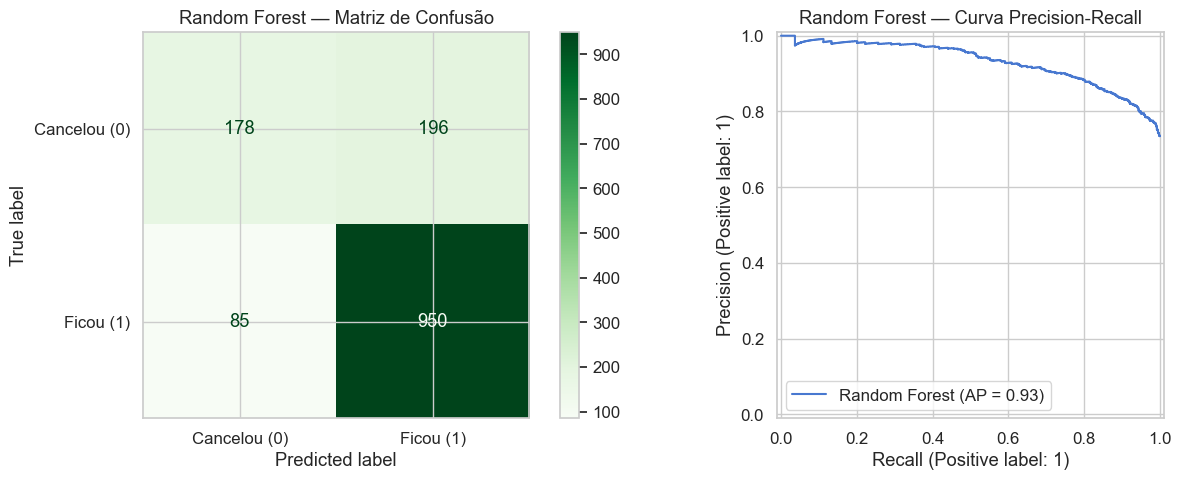

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["Cancelou (0)", "Ficou (1)"],
    cmap="Greens", ax=axes[0]
)
axes[0].set_title("Random Forest — Matriz de Confusão")

PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_rf, pos_label=1,
    name="Random Forest", ax=axes[1]
)
axes[1].set_title("Random Forest — Curva Precision-Recall")

plt.tight_layout()
plt.show()

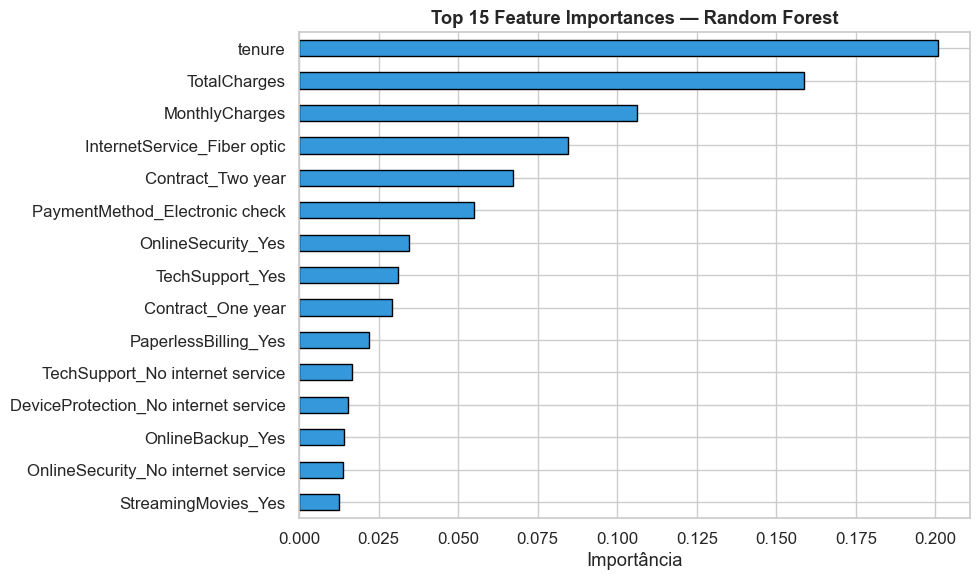

In [121]:
# Feature Importance — Random Forest
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.plot(kind="barh", ax=ax, color="#3498db", edgecolor="black")
ax.set_title("Top 15 Feature Importances — Random Forest", fontweight="bold")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.show()

### 5.3 Comparação dos Modelos

In [122]:
comparison = pd.DataFrame({
    "Modelo": ["Regressão Logística", "Random Forest"],
    "PR-AUC (minoritária)": [pr_auc_lr, pr_auc_rf],
    "Brier Score": [brier_lr, brier_rf],
}).set_index("Modelo")

print("Comparação dos Modelos Baseline:")
print("(PR-AUC: maior é melhor | Brier Score: menor é melhor)")
print()
comparison.round(4)

Comparação dos Modelos Baseline:
(PR-AUC: maior é melhor | Brier Score: menor é melhor)



,PR-AUC (minoritária),Brier Score
Modelo,,
Regressão Logística,0.6096,0.1415
Random Forest,0.6423,0.1388


---
## 6. DAG Causal

O grafo acíclico direcionado (DAG) abaixo representa a estrutura causal assumida para o problema de churn em telecomunicações, conforme a formulação do projeto.

### Estrutura do DAG

- **C → X**: As covariáveis do cliente (perfil demográfico, tipo de contrato, tempo de casa) influenciam quais serviços o cliente contrata — gerando **viés de seleção** nos dados observacionais.
- **C → Y**: As mesmas covariáveis afetam diretamente a probabilidade de retenção (ex: clientes com contratos longos têm menor churn).
- **X → Y**: Os tratamentos (TechSupport, StreamingTV, StreamingMovies) têm um **efeito causal direto** sobre a retenção — este é o efeito que queremos estimar.

### Premissa de Unconfoundedness

A premissa central é que, **condicionando nas covariáveis C observadas**, a atribuição do tratamento X é independente dos desfechos potenciais. Ou seja, não há confundidores não-observados. Essa premissa habilita o **Backdoor Adjustment**: ao controlar por C, podemos estimar $P(Y | do(X))$ a partir dos dados observacionais.

Na entrega final, utilizaremos Propensity Score Matching (PSM) ou IPW para operacionalizar esse ajuste, e os testes de refutação do DoWhy para avaliar a sensibilidade à violação dessa premissa.

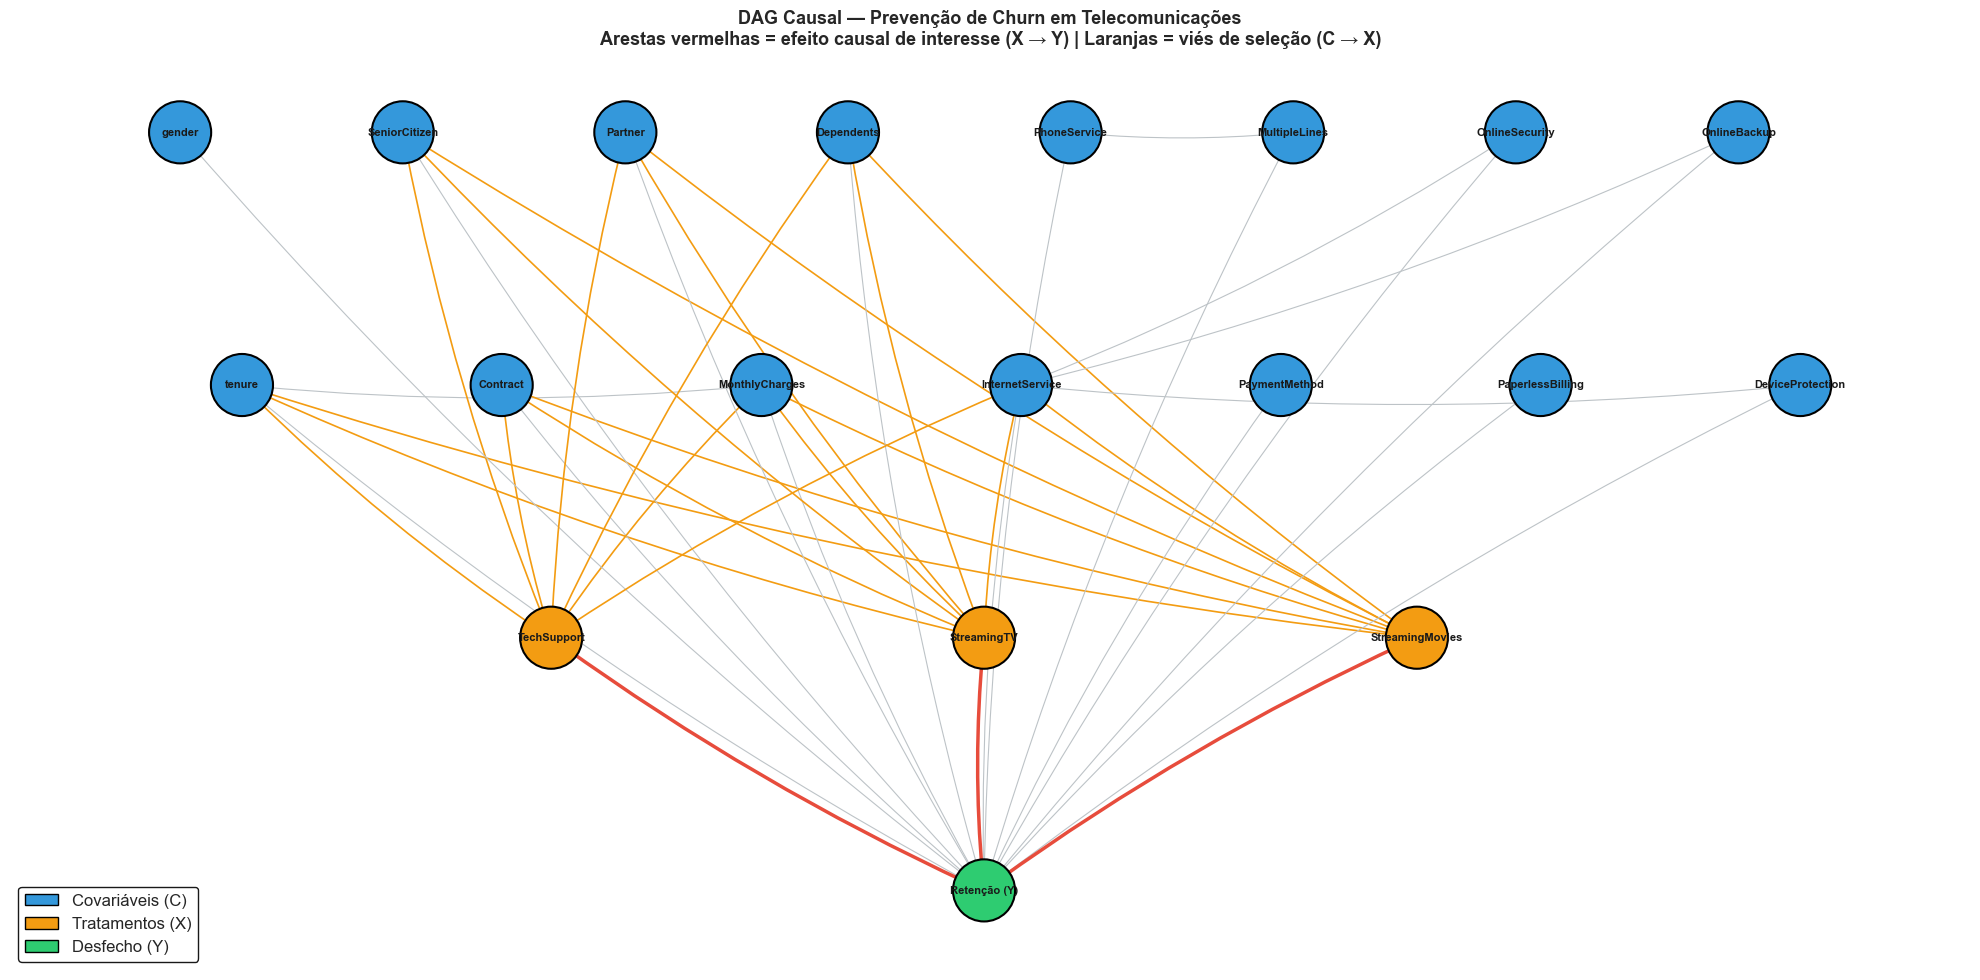

In [123]:
G = nx.DiGraph()

# -- Nós --
covariates_nodes = [
    "tenure", "Contract", "MonthlyCharges",
    "SeniorCitizen", "gender", "Partner",
    "Dependents", "InternetService",
    "PaymentMethod", "PaperlessBilling",
    "PhoneService", "MultipleLines",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
]
treatment_nodes = ["TechSupport", "StreamingTV", "StreamingMovies"]
outcome_node = "Retenção (Y)"

G.add_nodes_from(covariates_nodes)
G.add_nodes_from(treatment_nodes)
G.add_node(outcome_node)

# -- Arestas --
# C → X (covariáveis influenciam a adoção dos tratamentos)
confounders_to_treatment = [
    "tenure", "Contract", "MonthlyCharges", "SeniorCitizen",
    "InternetService", "Partner", "Dependents"
]
for c in confounders_to_treatment:
    for x in treatment_nodes:
        G.add_edge(c, x)

# C → Y (covariáveis influenciam a retenção diretamente)
for c in covariates_nodes:
    G.add_edge(c, outcome_node)

# X → Y (efeito causal dos tratamentos sobre a retenção)
for x in treatment_nodes:
    G.add_edge(x, outcome_node)

# Algumas relações entre covariáveis
G.add_edge("tenure", "TotalCharges" if "TotalCharges" in G.nodes else "MonthlyCharges")
G.add_edge("InternetService", "OnlineSecurity")
G.add_edge("InternetService", "OnlineBackup")
G.add_edge("InternetService", "DeviceProtection")
G.add_edge("PhoneService", "MultipleLines")

# -- Layout --
pos = {}

# Covariáveis em duas fileiras no topo
top_row = ["gender", "SeniorCitizen", "Partner", "Dependents",
           "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup"]
mid_row = ["tenure", "Contract", "MonthlyCharges", "InternetService",
           "PaymentMethod", "PaperlessBilling", "DeviceProtection"]

for i, node in enumerate(top_row):
    pos[node] = (i * 1.8, 3)
for i, node in enumerate(mid_row):
    pos[node] = (i * 2.1 + 0.5, 1.5)

# Tratamentos no meio
for i, node in enumerate(treatment_nodes):
    pos[node] = (3 + i * 3.5, 0)

# Desfecho embaixo
pos[outcome_node] = (6.5, -1.5)

# -- Cores por tipo de nó --
node_colors = []
for node in G.nodes():
    if node in treatment_nodes:
        node_colors.append("#f39c12")
    elif node == outcome_node:
        node_colors.append("#2ecc71")
    else:
        node_colors.append("#3498db")

# -- Desenhar --
fig, ax = plt.subplots(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000,
                       edgecolors="black", linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)

# Arestas C→Y em cinza claro, X→Y em vermelho forte, C→X em laranja
edge_colors = []
edge_widths = []
for u, v in G.edges():
    if u in treatment_nodes and v == outcome_node:
        edge_colors.append("#e74c3c")
        edge_widths.append(2.5)
    elif v in treatment_nodes:
        edge_colors.append("#f39c12")
        edge_widths.append(1.2)
    else:
        edge_colors.append("#bdc3c7")
        edge_widths.append(0.8)

nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths,
                       arrows=True, arrowsize=15, arrowstyle="->",
                       connectionstyle="arc3,rad=0.05", ax=ax)

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#3498db", edgecolor="black", label="Covariáveis (C)"),
    Patch(facecolor="#f39c12", edgecolor="black", label="Tratamentos (X)"),
    Patch(facecolor="#2ecc71", edgecolor="black", label="Desfecho (Y)"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=12,
          framealpha=0.9, edgecolor="black")

ax.set_title("DAG Causal — Prevenção de Churn em Telecomunicações\n"
             "Arestas vermelhas = efeito causal de interesse (X → Y) | "
             "Laranjas = viés de seleção (C → X)",
             fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

### Interpretação do DAG

As arestas **vermelhas** (X → Y) representam o efeito causal que queremos isolar na entrega final: o impacto de oferecer TechSupport, StreamingTV ou StreamingMovies sobre a retenção.

As arestas **laranjas** (C → X) representam o **viés de seleção**: clientes com certas características (ex: maior tenure, contrato longo) têm maior probabilidade de já possuir esses serviços. Se não controlarmos por C, a associação observacional entre X e Y mistura o efeito causal com esse viés.

O critério **Backdoor** nos diz que, ao condicionar em C, bloqueamos todos os caminhos espúrios entre X e Y, permitindo identificar o efeito causal $P(Y | do(X))$ a partir dos dados observacionais.

---
## 7. Validação da Premissa de Positividade (Propensity Score Overlap)

Para garantir que a inferência causal será possível na etapa final, precisamos provar a premissa de **Positividade (Overlap)**. Vamos calcular a probabilidade de um cliente receber o tratamento principal (`TechSupport`) dadas as suas covariáveis (Propensity Score) e verificar se as distribuições dos grupos Tratado e Controle se sobrepõem.

/Users/rafael/Desktop/MSc/Causal/TP/tpcausal/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


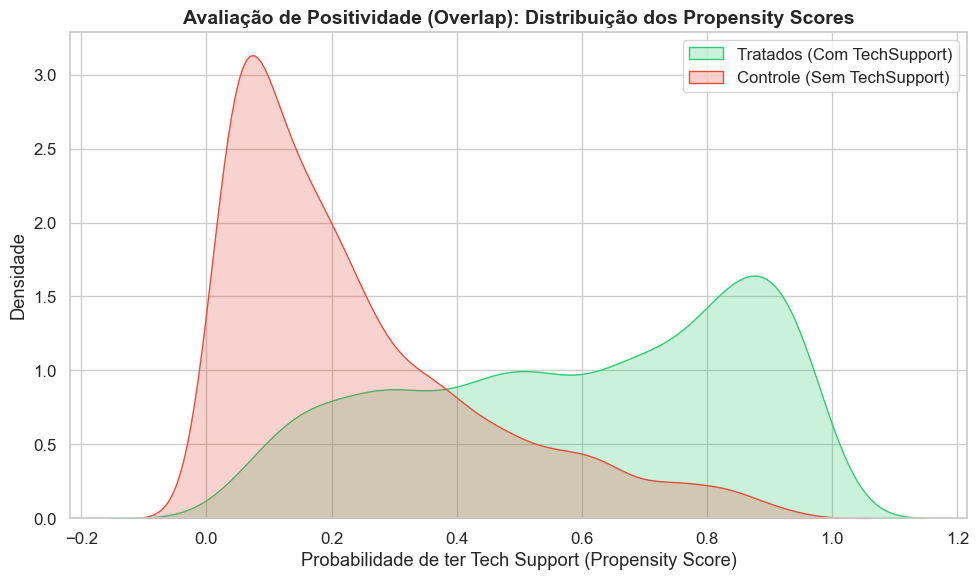

In [124]:
# 1. Preparar os dados para o Propensity Score Model
# Alvo: Ter TechSupport (Ignorando 'No internet service' para esta validação binária)
df_ps = df[df["TechSupport"] != "No internet service"].copy()
df_ps["Treat_TechSupport"] = (df_ps["TechSupport"] == "Yes").astype(int)

# Covariáveis (C) - Tudo exceto Tratamentos e Target
X_ps = df_ps[COVARIATES]
X_ps = pd.get_dummies(X_ps, drop_first=True)

# 2. Treinar um modelo Logístico simples para prever o Tratamento
ps_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
ps_model.fit(X_ps, df_ps["Treat_TechSupport"])

# 3. Extrair as probabilidades (Propensity Scores)
df_ps["Propensity_Score"] = ps_model.predict_proba(X_ps)[:, 1]

# 4. Plotar o Gráfico de Overlap
fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(data=df_ps[df_ps["Treat_TechSupport"] == 1], x="Propensity_Score", 
            fill=True, color="#2ecc71", label="Tratados (Com TechSupport)", ax=ax)
sns.kdeplot(data=df_ps[df_ps["Treat_TechSupport"] == 0], x="Propensity_Score", 
            fill=True, color="#e74c3c", label="Controle (Sem TechSupport)", ax=ax)

ax.set_title("Avaliação de Positividade (Overlap): Distribuição dos Propensity Scores", fontsize=14, fontweight="bold")
ax.set_xlabel("Probabilidade de ter Tech Support (Propensity Score)")
ax.set_ylabel("Densidade")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Estimação Causal Inicial (ATE via IPW)

Nesta seção, realizaremos a nossa primeira estimação causal. O objetivo é calcular o Efeito Médio do Tratamento (ATE) na base, isolando matematicamente o viés de seleção (efeito das covariáveis $C$) que identificamos na etapa de exploração.

Para isso, utilizaremos a técnica de **Ponderação pelo Inverso da Probabilidade (IPW - Inverse Probability Weighting)**. O IPW utiliza os *Propensity Scores* $e(C_i) = P(X=1 \mid C_i)$ calculados na seção anterior para reponderar as instâncias do dataset. Essa técnica atribui pesos maiores a observações raras (ex: clientes com baixa propensão que receberam o tratamento) e pesos menores a observações comuns, criando uma pseudo-população onde o tratamento $X$ se torna independente das covariáveis $C$ (simulando um ensaio clínico randomizado).

A fórmula do estimador causal IPW para o ATE é definida por:

$$\hat{ATE}_{IPW} = \frac{1}{N} \sum_{i=1}^{N} \left( \frac{X_i Y_i}{e(C_i)} - \frac{(1 - X_i) Y_i}{1 - e(C_i)} \right)$$

Onde:
* $X_i$: Variável indicadora de tratamento (1 se tem `TechSupport`, 0 caso contrário).
* $Y_i$: Desfecho de retenção (1 se ficou, 0 se cancelou).
* $e(C_i)$: Probabilidade prevista de receber o tratamento dadas as covariáveis (Propensity Score).

O bloco de código abaixo aplica essa formulação diretamente sobre os dados para contrastar o Efeito Observacional Ingênuo (enviesado) com o verdadeiro Efeito Causal Médio.

In [125]:
# ==========================================
# 8. Estimação Causal Inicial (ATE via IPW)
# ==========================================
# Vamos calcular o Efeito Médio do Tratamento usando Inverse Probability Weighting (IPW)

# 1. Recuperamos a variável alvo (Y = Retenção) para esta base filtrada
df_ps["Y_Retencao"] = df.loc[df_ps.index, "Y"]

# 2. Evitar divisão por zero ou pesos infinitos (Trimming/Clipping dos Propensity Scores)
# Limitamos as probabilidades entre 0.05 e 0.95
ps_clipped = np.clip(df_ps["Propensity_Score"], 0.05, 0.95)

# 3. Cálculo dos Pesos IPW
# Peso para os Tratados: 1 / PS
# Peso para o Controle: 1 / (1 - PS)
df_ps["IPW_Weight"] = np.where(
    df_ps["Treat_TechSupport"] == 1,
    1 / ps_clipped,
    1 / (1 - ps_clipped)
)

# 4. Cálculo do Efeito Ingênuo (Observacional Bruto)
media_tratados_ingenuo = df_ps[df_ps["Treat_TechSupport"] == 1]["Y_Retencao"].mean()
media_controle_ingenuo = df_ps[df_ps["Treat_TechSupport"] == 0]["Y_Retencao"].mean()
efeito_ingenuo = media_tratados_ingenuo - media_controle_ingenuo

# 5. Cálculo do Efeito Causal (ATE via IPW)
media_tratados_causal = np.average(
    df_ps[df_ps["Treat_TechSupport"] == 1]["Y_Retencao"], 
    weights=df_ps[df_ps["Treat_TechSupport"] == 1]["IPW_Weight"]
)
media_controle_causal = np.average(
    df_ps[df_ps["Treat_TechSupport"] == 0]["Y_Retencao"], 
    weights=df_ps[df_ps["Treat_TechSupport"] == 0]["IPW_Weight"]
)
ate_ipw = media_tratados_causal - media_controle_causal

# 6. Exibir os resultados
print("=== RESULTADOS DA ESTIMAÇÃO DO ATE ===")
print(f"Taxa de Retenção (Sem Suporte - Controle): {media_controle_ingenuo:.2%}")
print(f"Taxa de Retenção (Com Suporte - Tratado):  {media_tratados_ingenuo:.2%}")
print(f"-> EFEITO INGÊNUO (Viés incluído): Aumenta a retenção em {efeito_ingenuo*100:.2f} pontos percentuais.\n")

print("Após o Ajuste Causal (IPW):")
print(f"Retenção Contrafactual (Se todos tivessem Controle): {media_controle_causal:.2%}")
print(f"Retenção Contrafactual (Se todos tivessem Suporte):  {media_tratados_causal:.2%}")
print(f"-> EFEITO CAUSAL MÉDIO (ATE): Aumenta a retenção em {ate_ipw*100:.2f} pontos percentuais.\n")

vies_removido = (efeito_ingenuo - ate_ipw)
print(f"CONCLUSÃO: O Machine Learning tradicional superestimou o poder do TechSupport em {vies_removido*100:.2f} pontos percentuais devido ao viés de lealdade (tenure/contrato).")

=== RESULTADOS DA ESTIMAÇÃO DO ATE ===
Taxa de Retenção (Sem Suporte - Controle): 58.36%
Taxa de Retenção (Com Suporte - Tratado):  84.83%
-> EFEITO INGÊNUO (Viés incluído): Aumenta a retenção em 26.47 pontos percentuais.

Após o Ajuste Causal (IPW):
Retenção Contrafactual (Se todos tivessem Controle): 65.84%
Retenção Contrafactual (Se todos tivessem Suporte):  76.62%
-> EFEITO CAUSAL MÉDIO (ATE): Aumenta a retenção em 10.78 pontos percentuais.

CONCLUSÃO: O Machine Learning tradicional superestimou o poder do TechSupport em 15.69 pontos percentuais devido ao viés de lealdade (tenure/contrato).


---
## 9. Conclusões Parciais e Próximos Passos

### Achados da EDA
- O dataset apresenta desbalanceamento significativo (~73% retenção vs. ~27% churn)
- `tenure`, `Contract` e `MonthlyCharges` são os preditores mais fortes de retenção
- Clientes com Fiber Optic e contratos mês-a-mês apresentam as maiores taxas de cancelamento
- A associação observacional sugere que TechSupport tem forte relação com retenção, mas esta inclui confundimento (clientes que contratam TechSupport tendem a ter contratos mais longos)

### Modelos Baseline
- Ambos os modelos (Regressão Logística e Random Forest) foram treinados e avaliados com PR-AUC e Brier Score, conforme definido na proposta
- Esses estimadores-base servirão como componentes dos Meta-Learners na próxima etapa

### Próximos Passos (Entrega Final)
1. **Propensity Score Matching / IPW**: ajuste observacional para controlar o viés de seleção
2. **Meta-Learners (T-Learner / X-Learner)**: estimação do CATE individual para cada tratamento
3. **Unit Selection**: classificação dos clientes nos estratos causais (Always-takers, Never-takers, Defiers, Compliers)
4. **Otimização de Política**: seleção do tratamento ótimo por perfil de cliente
5. **Modelagem da funçao de benefício
6. **Testes de Refutação (DoWhy)**: placebo treatment e sensitivity analysis